# Condition Coverage & Therapeutic Area Analysis

Validates the condition dictionary (`ref.condition_dictionary`), study conditions (`norm.study_conditions`), and therapeutic area mapping (`norm.study_therapeutic_areas`).

**Key questions:**
1. How well does the condition dictionary cover free-text conditions?
2. What % of studies have at least one TA assignment?
3. How are studies distributed across TAs?
4. What are the top unmapped conditions (informs Phase 2C urgency)?

In [9]:


import duckdb
import matplotlib.pyplot as plt
import pandas as pd

conn = duckdb.connect('../data/clinical_trials.duckdb', read_only=True)
print("Connected to DuckDB")

Connected to DuckDB


## 1. Condition Dictionary Coverage

In [10]:
total_studies = conn.execute("SELECT COUNT(DISTINCT nct_id) FROM raw.studies").fetchone()[0]
total_conditions = conn.execute("SELECT COUNT(*) FROM raw.conditions").fetchone()[0]
unique_conditions = conn.execute("SELECT COUNT(DISTINCT LOWER(name)) FROM raw.conditions").fetchone()[0]
dict_size = conn.execute("SELECT COUNT(*) FROM ref.condition_dictionary").fetchone()[0]

print(f"Total condition rows:      {total_conditions:,}")
print(f"Unique condition names:    {unique_conditions:,}")
print(f"Dictionary entries:        {dict_size:,} ({100*dict_size/unique_conditions:.1f}% of unique names)")

print("\nDictionary entries by method and confidence:")
dict_stats = conn.execute("""
    SELECT mapping_method, confidence, COUNT(*) as entries
    FROM ref.condition_dictionary
    GROUP BY mapping_method, confidence
    ORDER BY mapping_method, confidence
""").fetchdf()
print(dict_stats.to_string(index=False))

# Phase 7B: norm.study_conditions now keys on condition_id (FK → entities.condition)
# instead of a canonical_term string. Labels are looked up via join at query time.
print("\nStudy-level condition coverage:")
studies_with_canonical = conn.execute(
    "SELECT COUNT(DISTINCT nct_id) FROM norm.study_conditions WHERE condition_id IS NOT NULL"
).fetchone()[0]
mapped_rows = conn.execute(
    "SELECT COUNT(*) FROM norm.study_conditions WHERE condition_id IS NOT NULL"
).fetchone()[0]
print(f"  Studies with ≥1 canonical condition: {studies_with_canonical:,}/{total_studies:,} ({100*studies_with_canonical/total_studies:.1f}%)")
print(f"  Condition rows mapped: {mapped_rows:,}/{total_conditions:,} ({100*mapped_rows/total_conditions:.1f}%)")

Total condition rows:      1,056,711
Unique condition names:    128,650
Dictionary entries:        33,215 (25.8% of unique names)

Dictionary entries by method and confidence:
mapping_method confidence  entries
     1:1-study       high    22852
cancer-synonym       high      492
 co-occurrence       high      614
 co-occurrence     medium     4763
         exact       high     4494

Study-level condition coverage:
  Studies with ≥1 canonical condition: 530,197/590,350 (89.8%)
  Condition rows mapped: 844,806/1,056,711 (79.9%)


## 2. Sample Mappings by Method (Spot-Check)

In [11]:
for method in ['exact', '1:1-study', 'co-occurrence', 'cancer-synonym']:
    print(f"\n=== {method} (10 samples) ===")
    sample = conn.execute(f"""
        SELECT d.condition_name, e.canonical_term, d.confidence
        FROM ref.condition_dictionary d
        JOIN entities.condition e ON d.condition_id = e.condition_id
        WHERE d.mapping_method = '{method}'
        ORDER BY d.condition_name
        LIMIT 10
    """).fetchdf()
    print(sample.to_string(index=False))


=== exact (10 samples) ===
                                      condition_name                                       canonical_term confidence
                           16p11.2 deletion syndrome                            16p11.2 Deletion Syndrome       high
                             22q11 deletion syndrome                              22q11 Deletion Syndrome       high
     3-hydroxy-3-methylglutaryl-coa lyase deficiency      3-Hydroxy-3-Methylglutaryl-CoA Lyase Deficiency       high
3-hydroxy-3-methylglutaryl-coa synthase 2 deficiency 3-Hydroxy-3-Methylglutaryl-CoA Synthase 2 Deficiency       high
          3-hydroxyacyl-coa dehydrogenase deficiency           3-Hydroxyacyl-CoA Dehydrogenase Deficiency       high
       3-methylcrotonyl coa carboxylase 1 deficiency        3-methylcrotonyl CoA carboxylase 1 deficiency       high
       3-methylcrotonyl coa carboxylase 2 deficiency        3-methylcrotonyl CoA carboxylase 2 deficiency       high
                                    

## 3. TA Coverage & Distribution

Studies with TA assignment: 462,712/590,350 (78.4%)



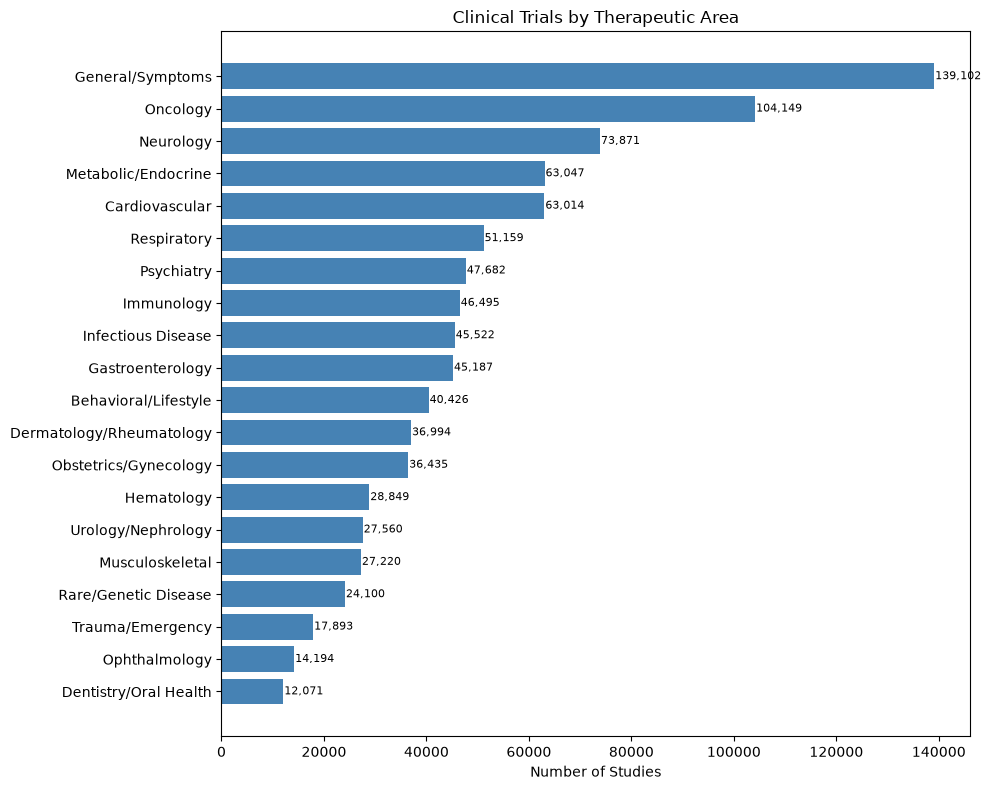

Note: Studies can appear in multiple TAs (multi-label). Total unique studies with TA: 462,712


In [12]:
studies_with_ta = conn.execute("SELECT COUNT(DISTINCT nct_id) FROM norm.study_therapeutic_areas").fetchone()[0]
print(f"Studies with TA assignment: {studies_with_ta:,}/{total_studies:,} ({100*studies_with_ta/total_studies:.1f}%)\n")

ta_dist = conn.execute("""
    SELECT therapeutic_area,
           COUNT(DISTINCT nct_id) AS study_count
    FROM norm.study_therapeutic_areas
    GROUP BY therapeutic_area
    ORDER BY study_count DESC
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(ta_dist['therapeutic_area'][::-1], ta_dist['study_count'][::-1], color='steelblue')
ax.set_xlabel('Number of Studies')
ax.set_title('Clinical Trials by Therapeutic Area')
for i, (ta, count) in enumerate(zip(ta_dist['therapeutic_area'][::-1], ta_dist['study_count'][::-1])):
    ax.text(count + 200, i, f'{count:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Note: Studies can appear in multiple TAs (multi-label). Total unique studies with TA: {studies_with_ta:,}")

## 4. Multi-label Analysis & Top Unmapped Conditions

Therapeutic areas per study:
 ta_count  num_studies
        1       162279
        2       179090
        3        81658
        4        27210
        5         8069
        6         2478
        7         1049
        8          396
        9          222
       10           97
       11           86
       12           29
       13           17
       14           12
       15            9
       16            4
       17            4
       18            2
       19            1


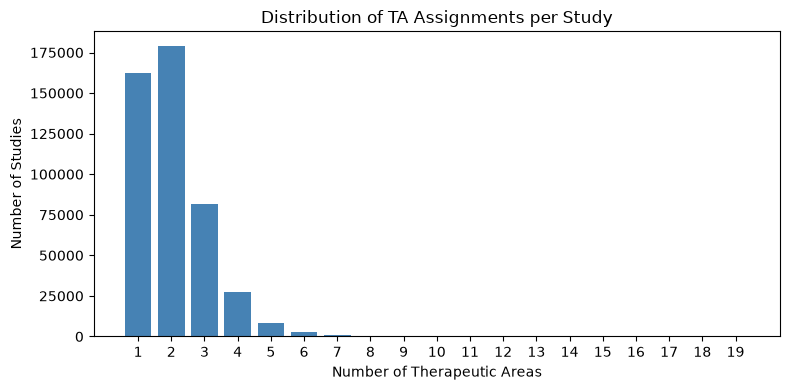

In [13]:
ta_per_study = conn.execute("""
    SELECT ta_count, COUNT(*) AS num_studies
    FROM (
        SELECT nct_id, COUNT(DISTINCT therapeutic_area) AS ta_count
        FROM norm.study_therapeutic_areas
        GROUP BY nct_id
    )
    GROUP BY ta_count
    ORDER BY ta_count
""").fetchdf()

print("Therapeutic areas per study:")
print(ta_per_study.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ta_per_study['ta_count'], ta_per_study['num_studies'], color='steelblue')
ax.set_xlabel('Number of Therapeutic Areas')
ax.set_ylabel('Number of Studies')
ax.set_title('Distribution of TA Assignments per Study')
ax.set_xticks(ta_per_study['ta_count'])
plt.tight_layout()
plt.show()

## 5. Top Unmapped Conditions & Coverage Gap

In [14]:
unmapped = conn.execute("""
    SELECT condition_name, COUNT(DISTINCT nct_id) AS study_count
    FROM norm.study_conditions
    WHERE condition_id IS NULL
    GROUP BY condition_name
    ORDER BY study_count DESC
    LIMIT 30
""").fetchdf()

print(f"Top 30 unmapped conditions (no entity match in dictionary):\n")
print(unmapped.to_string(index=False))

print("\n\nCoverage gap breakdown:")
no_conditions = conn.execute("""
    SELECT COUNT(DISTINCT s.nct_id)
    FROM raw.studies s
    LEFT JOIN raw.conditions c ON s.nct_id = c.nct_id
    WHERE c.nct_id IS NULL
""").fetchone()[0]
has_conditions_no_browse = conn.execute("""
    SELECT COUNT(DISTINCT c.nct_id)
    FROM raw.conditions c
    LEFT JOIN raw.browse_conditions bc ON c.nct_id = bc.nct_id
    WHERE bc.nct_id IS NULL
""").fetchone()[0]
has_browse_no_ta = conn.execute("""
    SELECT COUNT(DISTINCT bc.nct_id)
    FROM raw.browse_conditions bc
    LEFT JOIN norm.study_therapeutic_areas sta ON bc.nct_id = sta.nct_id
    WHERE sta.nct_id IS NULL
""").fetchone()[0]

print(f"  Studies with no conditions at all:           {no_conditions:,}")
print(f"  Studies with conditions but no MeSH mapping: {has_conditions_no_browse:,}")
print(f"  Studies with MeSH mapping but no TA match:   {has_browse_no_ta:,}")
print(f"  Total without TA:                            {total_studies - studies_with_ta:,}")

Top 30 unmapped conditions (no entity match in dictionary):

                                                               condition_name  study_count
                                                       Overweight and Obesity          783
                             Unspecified Adult Solid Tumor, Protocol Specific          758
                                    Multiple Myeloma and Plasma Cell Neoplasm          295
                                                          Depression, Anxiety          291
                                                              Dexmedetomidine          237
                                                      Artificial Intelligence          226
                                                         Obesity & Overweight          196
                                         Recurrent Small Lymphocytic Lymphoma          172
                                                                   Pediatrics          152
                             

In [15]:
conn.close()
print("Done.")

Done.
